# Midway And Final-Stage Results

This notebook is split into three sections:

1. **Midway deliverables**: baseline comparison between `ControlNet` and `IP-Adapter`
2. **Final-stage hard switch**: `naive_combined` and `tau` threshold experiments
3. **Final-stage smooth schedule**: sigmoid-like transition approximated on top of the hard-switch work

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
HARD_EXPERIMENT_NAME = 'search_100_conflict'
SMOOTH_EXPERIMENT_NAME = 'search_100_conflict_smooth'

def read_csv_if_exists(path, **kwargs):
    return pd.read_csv(path, **kwargs) if path.exists() else pd.DataFrame()

def read_json_if_exists(path):
    return json.loads(path.read_text(encoding='utf-8')) if path.exists() else {}

manifest = pd.read_csv(ROOT / 'assets' / 'data' / 'coco2017_midway' / 'subset_manifest.csv', dtype={'sample_id': str})
manifest['sample_id'] = manifest['sample_id'].str.zfill(12)

baseline_metrics = read_csv_if_exists(ROOT / 'outputs' / 'midway_baselines' / 'metrics' / 'per_sample_metrics.csv', dtype={'sample_id': str})
if not baseline_metrics.empty:
    baseline_metrics['sample_id'] = baseline_metrics['sample_id'].str.zfill(12)

hard_root = ROOT / 'outputs' / 'combined_experiments' / HARD_EXPERIMENT_NAME
hard_manifest = read_csv_if_exists(hard_root / 'experiment_manifest.csv', dtype={'sample_id': str})
if not hard_manifest.empty:
    hard_manifest['sample_id'] = hard_manifest['sample_id'].astype(str)
hard_metrics = read_csv_if_exists(hard_root / 'per_sample_metrics.csv', dtype={'sample_id': str})
if not hard_metrics.empty:
    hard_metrics['sample_id'] = hard_metrics['sample_id'].astype(str)
hard_search = read_csv_if_exists(hard_root / 'search_summary.csv')
hard_config = read_json_if_exists(hard_root / 'experiment_config.json')

smooth_root = ROOT / 'outputs' / 'combined_experiments' / SMOOTH_EXPERIMENT_NAME
smooth_manifest = read_csv_if_exists(smooth_root / 'experiment_manifest.csv', dtype={'sample_id': str})
if not smooth_manifest.empty:
    smooth_manifest['sample_id'] = smooth_manifest['sample_id'].astype(str)
smooth_metrics = read_csv_if_exists(smooth_root / 'per_sample_metrics.csv', dtype={'sample_id': str})
if not smooth_metrics.empty:
    smooth_metrics['sample_id'] = smooth_metrics['sample_id'].astype(str)
smooth_search = read_csv_if_exists(smooth_root / 'search_summary.csv')
smooth_trace = read_csv_if_exists(smooth_root / 'progressive_search_trace.csv')
smooth_config = read_json_if_exists(smooth_root / 'experiment_config.json')

print('Loaded baseline rows:', len(baseline_metrics))
print('Loaded hard-switch rows:', len(hard_metrics))
print('Loaded smooth-schedule rows:', len(smooth_metrics))

Loaded baseline rows: 2000
Loaded hard-switch rows: 600
Loaded smooth-schedule rows: 0


## Midway Deliverables

This section is the required midway content: baseline trade-off between `ControlNet` and `IP-Adapter`.

canny_mse                 clip_similarity                
                mean  median     std            mean  median     std
mode                                                                
controlnet    0.1368  0.1209  0.0782          0.7874  0.8002  0.0883
ip_adapter    0.1732  0.1615  0.0847          0.8457  0.8531  0.0612

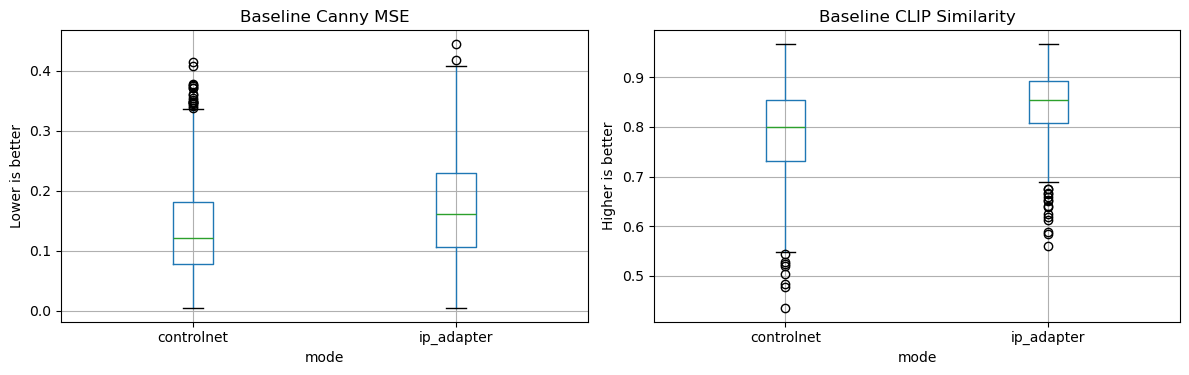

In [2]:
if not baseline_metrics.empty:
    display(baseline_metrics.groupby('mode')[['canny_mse', 'clip_similarity']].agg(['mean', 'median', 'std']).round(4))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    baseline_metrics.boxplot(column='canny_mse', by='mode', ax=axes[0])
    axes[0].set_title('Baseline Canny MSE')
    axes[0].set_ylabel('Lower is better')
    baseline_metrics.boxplot(column='clip_similarity', by='mode', ax=axes[1])
    axes[1].set_title('Baseline CLIP Similarity')
    axes[1].set_ylabel('Higher is better')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

## Final-Stage Hard Switch

Current hard-switch interpretation:
- `tau` is the fraction of denoising completed before the control emphasis changes
- larger `tau` means structure control persists longer and semantic control starts later
- therefore larger `tau` usually lowers `Canny MSE` but can also lower `CLIP similarity`

This is a threshold schedule, not the smooth sigmoid transition in the proposal figure.

### Hard-Switch Experiment Config

,pairing,sample_size,sample_seed,pairing_seed,taus,num_inference_steps,guidance_scale,controlnet_scale,ip_adapter_scale
0,conflict,100,10623,10624,"[0.25, 0.4, 0.5, 0.6, 0.75]",30,7.5,1.0,0.8


### Hard-Switch Search Summary

,mode,canny_mse_mean,canny_mse_std,canny_mse_median,clip_similarity_mean,clip_similarity_std,clip_similarity_median,canny_score,clip_score,balanced_score
0,naive_combined,0.1297,0.0729,0.1208,0.6453,0.1097,0.6496,1.0000,0.1511,0.5755
1,tau_0p25,0.1713,0.0698,0.1657,0.8098,0.0699,0.8202,0.0000,1.0000,0.5000
2,tau_0p4,0.1659,0.0758,0.1551,0.7643,0.0763,0.7617,0.1312,0.7652,0.4482
3,tau_0p5,0.1613,0.0775,0.1507,0.7172,0.0963,0.7293,0.2424,0.5223,0.3823
4,tau_0p6,0.1559,0.0769,0.1489,0.6631,0.0947,0.6888,0.3714,0.2433,0.3073
5,tau_0p75,0.1518,0.0782,0.1392,0.6160,0.0977,0.6240,0.4692,0.0000,0.2346


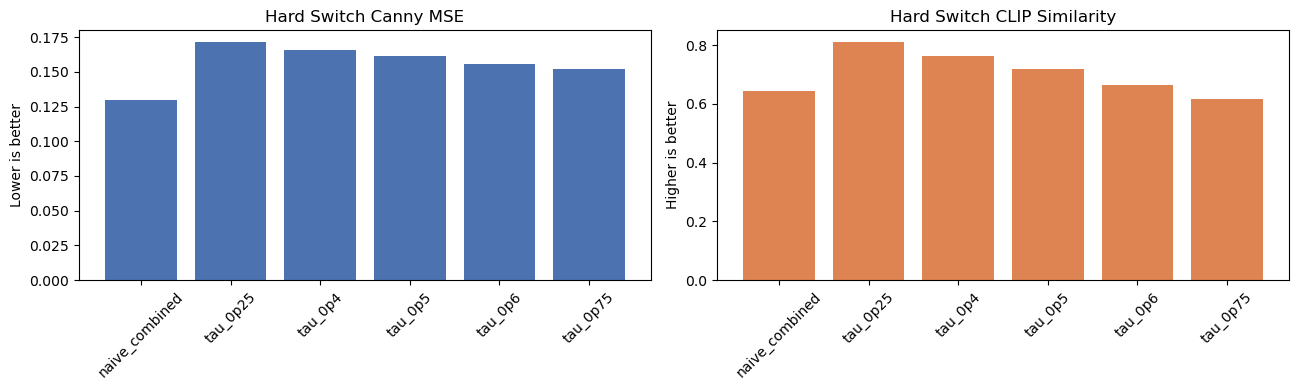

In [3]:
if not hard_search.empty:
    display(Markdown('### Hard-Switch Experiment Config'))
    display(pd.DataFrame([hard_config]))
    display(Markdown('### Hard-Switch Search Summary'))
    display(hard_search.round(4))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].bar(hard_search['mode'], hard_search['canny_mse_mean'], color='#4C72B0')
    axes[0].set_title('Hard Switch Canny MSE')
    axes[0].set_ylabel('Lower is better')
    axes[0].tick_params(axis='x', rotation=45)
    axes[1].bar(hard_search['mode'], hard_search['clip_similarity_mean'], color='#DD8452')
    axes[1].set_title('Hard Switch CLIP Similarity')
    axes[1].set_ylabel('Higher is better')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## Final-Stage Smooth Schedule

The smooth schedule adds three freedoms without a full 3D grid search:
- `tau`: where the transition is centered
- `sharpness`: how steep the transition is
- maximum control strengths for `ControlNet` and `IP-Adapter`

Search strategy:
1. fix sharpness and max scales, search `tau`
2. fix best `tau`, search `sharpness`
3. fix best `tau` and `sharpness`, search `IP-Adapter` max scale
4. fix the previous best settings, search `ControlNet` max scale

This is a progressive one-dimensional search, not a brute-force 3D grid.

In [4]:
if not smooth_search.empty:
    display(Markdown('### Smooth-Schedule Experiment Config'))
    display(pd.DataFrame([smooth_config]))
    display(Markdown('### Smooth-Schedule Search Summary'))
    display(smooth_search.round(4))
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(smooth_search['canny_mse_mean'], smooth_search['clip_similarity_mean'], s=80)
    for _, row in smooth_search.iterrows():
        ax.annotate(row['mode'], (row['canny_mse_mean'], row['clip_similarity_mean']), textcoords='offset points', xytext=(5, 5))
    ax.set_title('Smooth Schedule Trade-Off')
    ax.set_xlabel('Canny MSE mean (lower is better)')
    ax.set_ylabel('CLIP similarity mean (higher is better)')
    plt.tight_layout()
    plt.show()

In [5]:
if not smooth_trace.empty:
    display(Markdown('### Progressive Search Trace'))
    display(smooth_trace.round(4))

In [6]:
def show_combined_gallery(manifest_frame, metrics_frame, root_dir, modes, sample_ids):
    for sample_id in sample_ids:
        row = manifest_frame.loc[manifest_frame['sample_id'] == sample_id].iloc[0]
        panels = []
        if 'structure_image_path' in row.index:
            panels.append(('Structure image', Image.open(row.structure_image_path).convert('RGB')))
        panels.append(('Canny', Image.open(row.edge_path).convert('L')))
        if 'semantic_image_path' in row.index:
            panels.append(('Semantic reference', Image.open(row.semantic_image_path).convert('RGB')))
        else:
            panels.append(('Reference', Image.open(row.image_path).convert('RGB')))
        for mode in modes:
            image_path = root_dir / mode / 'images' / f'{sample_id}.png'
            if image_path.exists():
                panels.append((mode, Image.open(image_path).convert('RGB')))
        fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
        if len(panels) == 1:
            axes = [axes]
        for axis, (title, image) in zip(axes, panels):
            axis.imshow(image, cmap='gray' if image.mode == 'L' else None)
            axis.set_title(title)
            axis.axis('off')
        fig.suptitle(row.caption if 'caption' in row.index else sample_id)
        plt.tight_layout()
        plt.show()
        display(metrics_frame.loc[metrics_frame['sample_id'] == sample_id, ['mode', 'canny_mse', 'clip_similarity']].round(4))

### Hard-Switch Representative Samples

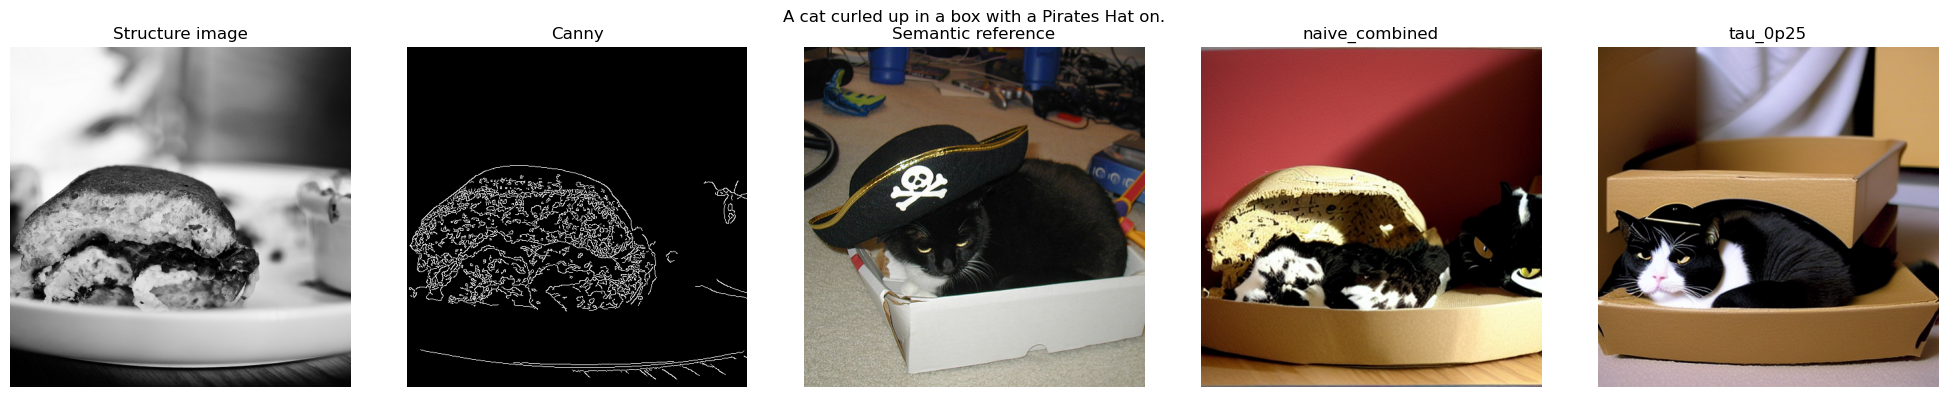

,mode,canny_mse,clip_similarity
0,naive_combined,0.0716,0.6613
1,tau_0p25,0.0792,0.7202
2,tau_0p4,0.0915,0.7106
3,tau_0p5,0.0931,0.6678
4,tau_0p6,0.0851,0.7097
5,tau_0p75,0.0721,0.6990


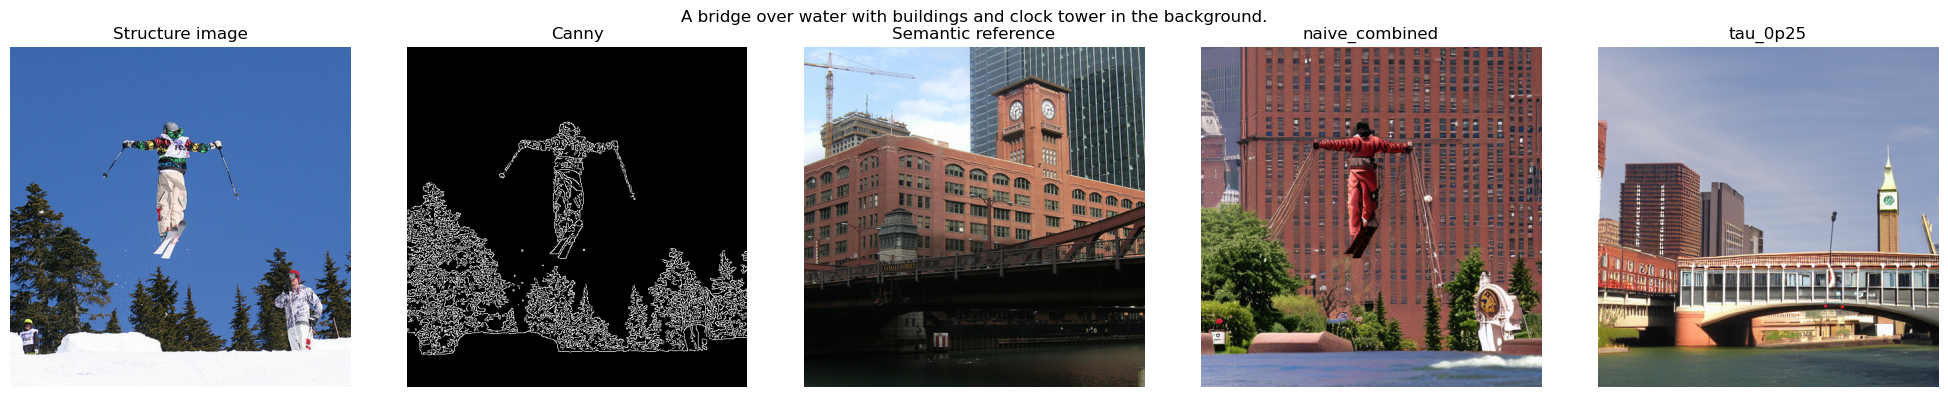

,mode,canny_mse,clip_similarity
6,naive_combined,0.1896,0.5229
7,tau_0p25,0.1489,0.8097
8,tau_0p4,0.1640,0.6975
9,tau_0p5,0.1501,0.6040
10,tau_0p6,0.1106,0.4855
11,tau_0p75,0.1187,0.5031


In [7]:
if not hard_search.empty and not hard_metrics.empty:
    display(Markdown('### Hard-Switch Representative Samples'))
    best_hard_tau = next((mode for mode in hard_search['mode'].tolist() if mode != 'naive_combined'), None)
    hard_modes = ['naive_combined'] + ([best_hard_tau] if best_hard_tau is not None else [])
    show_combined_gallery(hard_manifest, hard_metrics, hard_root, hard_modes, hard_metrics['sample_id'].drop_duplicates().head(2).tolist())

if not smooth_search.empty and not smooth_metrics.empty:
    display(Markdown('### Smooth-Schedule Representative Samples'))
    best_smooth = smooth_search.iloc[0]['mode']
    show_combined_gallery(smooth_manifest, smooth_metrics, smooth_root, [best_smooth], smooth_metrics['sample_id'].drop_duplicates().head(2).tolist())